# DL-02 · Neural Networks from Scratch

**Prerequisites:** FND-04, CML-02, and DL-01  
**Estimated study time:** 10–12 hours, including practice  
**Next lesson:** DL-03 · Backpropagation

DL-01 taught reliable PyTorch mechanics. Now we open the model itself.

A feed-forward neural network is a composition of affine transformations and
nonlinear activations. We will calculate one neuron, build one hidden layer in
NumPy, derive every gradient for that specific network, verify those gradients
numerically, and then reproduce the same computation in PyTorch.

### Scope boundary

This lesson covers binary classification with one hidden layer. DL-03 generalizes
the chain rule into reverse-mode automatic differentiation for arbitrary computation
graphs. DL-04 covers regularization and stable deep training.

Universal approximation means suitable weights exist under stated conditions. It
does not guarantee that training finds them, that finite data supports them, or that
the resulting model generalizes.


> **Canonical learner route · module DL-02 of 67**
>
> Required prerequisites: **FND-04, CML-02, DL-01** · Previous: **DL-01** ·
> Next after mastery: **DL-03** · Expected first-pass workload:
> **5–8 hours**
>
> **Core path:** intuition, objectives, foundations, runnable implementation,
> failure modes, and assessed exercises. **Extension path:** history, production,
> tradeoffs, and interview material may be revisited after the core pass.
> Do not continue merely because every cell ran. Continue when you can complete
> the independent exercise and teach-back without notes. The canonical route in
> `docs/CURRICULUM_PATH.json` is authoritative when section-local file order and
> prerequisite order differ.


## 1 · What you will be able to do

By the end, you will be able to:

- calculate a neuron's weighted sum and activation manually;
- trace every shape through a batched hidden layer;
- prove that stacked affine maps without activation remain affine;
- compare sigmoid, tanh, and ReLU by output and derivative behavior;
- distinguish logits, probabilities, decisions, and loss;
- calculate stable binary cross-entropy directly from logits;
- count parameters in a two-layer network;
- choose Xavier or He initialization from the activation;
- derive gradients for weights and biases in a two-layer network;
- implement the complete forward and backward pass in NumPy;
- verify analytical gradients with finite differences;
- fit preprocessing and models on training data only;
- select and restore a checkpoint using validation loss;
- inspect a learned hidden representation without using test rows;
- reproduce NumPy logits and gradients in PyTorch;
- evaluate the frozen model once on sealed test data.

### Learning path

```mermaid
flowchart LR
    A[One neuron] --> B[Batched layer]
    B --> C[Nonlinearity]
    C --> D[Two-layer forward pass]
    D --> E[Logit loss]
    E --> F[Two-layer chain rule]
    F --> G[NumPy implementation]
    G --> H[Gradient check]
    H --> I[Validation checkpoint]
    I --> J[PyTorch verification]
    J --> K[One sealed test]
```

Weighted sums  
→ required before a neuron  
→ because a neuron begins as the same affine score used in logistic regression.

Scalar chain rule  
→ required before matrix gradients  
→ because matrix formulas collect many scalar derivative paths.

Gradient checking  
→ required before trusting scratch training  
→ because an incorrect derivative may still produce a plausible-looking loss curve.


## 2 · The practical problem: XOR defeats one straight boundary

XOR returns positive when exactly one input is positive:

| $x_1$ | $x_2$ | XOR target |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The two positive corners are diagonal from each other. No single straight line can
put both positives on one side and both negatives on the other.

A hidden layer can learn new coordinates. The output layer then draws a straight
boundary in that learned space. This is **representation learning**: the network
changes the features presented to its final linear decision.

XOR proves that a hidden nonlinear representation can add expressive power. It does
not prove neural networks are the best model for every dataset.


In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from torch import nn

# Keep XOR tiny so we can inspect every row and isolate the geometry problem.
xor_features = np.array(
    [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
)
xor_targets = np.array([0, 1, 1, 0])

xor_linear_model = LogisticRegression(C=1e6, random_state=42)
xor_linear_model.fit(xor_features, xor_targets)
xor_linear_predictions = xor_linear_model.predict(xor_features)

print("XOR predictions from one linear boundary:", xor_linear_predictions)
print("XOR accuracy:", accuracy_score(xor_targets, xor_linear_predictions))

assert accuracy_score(xor_targets, xor_linear_predictions) < 1.0


XOR predictions from one linear boundary: [0 0 0 0]
XOR accuracy: 0.5


## 3 · Calculate one neuron before building a layer

A neuron first calculates a logit:

$$
z=w_1x_1+w_2x_2+b
$$

**Symbols:** $x_1,x_2$ are inputs; $w_1,w_2$ are learned weights; $b$ is bias; and
$z$ is the raw output before activation.

Let $x=[2,3]$, $w=[0.5,-1]$, and $b=0.25$:

$$
z=(0.5)(2)+(-1)(3)+0.25=-1.75
$$

A sigmoid output is $\sigma(z)=1/(1+e^{-z})\approx0.148$. That number can be read
as a binary probability only when sigmoid is the declared output link and the model
has been trained and evaluated for that purpose.

Hidden neurons need not use sigmoid. They commonly use tanh, ReLU, GELU, or another
nonlinearity appropriate to the architecture.


In [2]:
def stable_sigmoid(values):
    '''Calculate sigmoid without overflowing for large positive or negative inputs.'''
    values = np.asarray(values, dtype=float)

    # Use two equivalent formulas: each avoids exponentiating a large positive number.
    positive_mask = values >= 0
    results = np.empty_like(values)
    results[positive_mask] = 1 / (1 + np.exp(-values[positive_mask]))
    negative_exponentials = np.exp(values[~positive_mask])
    results[~positive_mask] = negative_exponentials / (1 + negative_exponentials)
    return results


neuron_inputs = np.array([2.0, 3.0])
neuron_weights = np.array([0.5, -1.0])
neuron_bias = 0.25
neuron_logit = neuron_inputs @ neuron_weights + neuron_bias
neuron_output = stable_sigmoid(np.array([neuron_logit]))[0]

print("logit:", neuron_logit)
print("sigmoid output:", round(float(neuron_output), 4))

assert np.isclose(neuron_logit, -1.75)


logit: -1.75
sigmoid output: 0.148


## 4 · A layer batches many neurons, and nonlinearity prevents collapse

For batch $X\in\mathbb R^{B\times d}$ and $h$ hidden units:

$$
Z_1=XW_1+b_1,\qquad A_1=g(Z_1)
$$

**Symbols:** $B$ is batch size; $d$ is input width; $h$ is hidden width;
$W_1\in\mathbb R^{d\times h}$; $b_1\in\mathbb R^h$; and $A_1$ is the hidden
representation.

Without activation, two affine layers collapse:

$$
(XW_1+b_1)W_2+b_2=X(W_1W_2)+(b_1W_2+b_2)
$$

The result is another affine map. Depth without nonlinear activation cannot solve
XOR. The activation changes the geometry between layers.


In [3]:
layer_inputs = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
first_weights = np.array([[1.0, -1.0, 0.5], [0.5, 2.0, -0.5]])
first_bias = np.array([0.1, 0.2, 0.3])
second_weights = np.array([[1.0], [-0.5], [2.0]])
second_bias = np.array([0.4])

# Calculate the long route first, then combine its weights and biases algebraically.
two_affine_layers = (layer_inputs @ first_weights + first_bias) @ second_weights + second_bias
collapsed_weights = first_weights @ second_weights
collapsed_bias = first_bias @ second_weights + second_bias
one_collapsed_layer = layer_inputs @ collapsed_weights + collapsed_bias

print("input shape:", layer_inputs.shape)
print("hidden pre-activation shape:", (layer_inputs @ first_weights + first_bias).shape)
print("output shape:", two_affine_layers.shape)
print("two affine layers equal one collapsed layer:", np.allclose(two_affine_layers, one_collapsed_layer))

assert np.allclose(two_affine_layers, one_collapsed_layer)


input shape: (3, 2)
hidden pre-activation shape: (3, 3)
output shape: (3, 1)
two affine layers equal one collapsed layer: True


## 5 · Activation choice changes both representation and gradient flow

| Activation | Output | Derivative | Main caution |
|---|---|---|---|
| sigmoid | $\sigma(z)$ | $\sigma(z)(1-\sigma(z))$ | saturates near 0 and 1 |
| tanh | $\tanh(z)$ | $1-\tanh^2(z)$ | saturates at large magnitude |
| ReLU | $\max(0,z)$ | 1 for positive, 0 for negative | inactive units can receive zero local gradient |

ReLU avoids sigmoid-style saturation on its positive side, but it does not guarantee
healthy gradients through a deep network. Products of weights and derivatives can
still shrink or explode. DL-03 and DL-04 develop that story.

Tanh is convenient for the small scratch network because it is smooth, zero-centered,
and has an easy derivative. Modern architectures often use ReLU-family or GELU
activations.


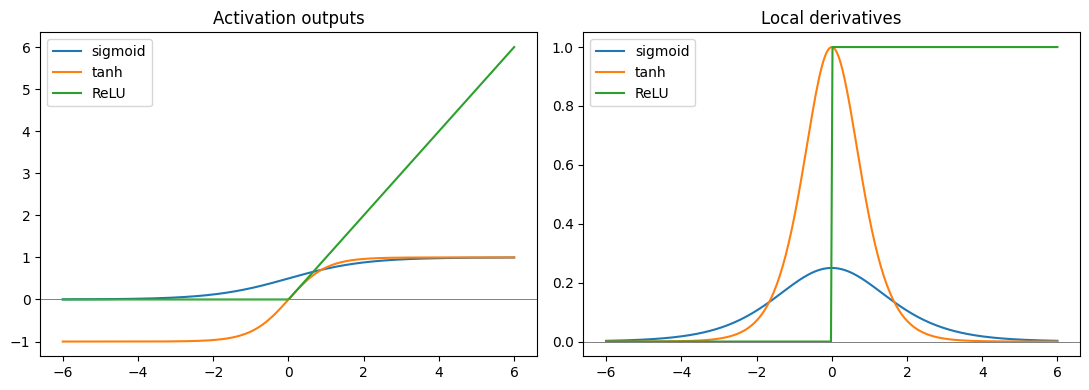

In [4]:
activation_inputs = np.linspace(-6, 6, 300)
sigmoid_outputs = stable_sigmoid(activation_inputs)
activation_curves = {
    "sigmoid": (sigmoid_outputs, sigmoid_outputs * (1 - sigmoid_outputs)),
    "tanh": (np.tanh(activation_inputs), 1 - np.tanh(activation_inputs) ** 2),
    "ReLU": (np.maximum(0, activation_inputs), (activation_inputs > 0).astype(float)),
}

# Plot outputs beside local slopes: learning depends on both views.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for activation_name, (outputs, derivatives) in activation_curves.items():
    axes[0].plot(activation_inputs, outputs, label=activation_name)
    axes[1].plot(activation_inputs, derivatives, label=activation_name)
axes[0].set_title("Activation outputs")
axes[1].set_title("Local derivatives")
for axis in axes:
    axis.axhline(0, color="gray", linewidth=0.7)
    axis.legend()
plt.tight_layout()
plt.show()


## 6 · Trace the two-layer forward pass from inputs to stable loss

Our binary network uses tanh hidden units and one output logit:

$$
Z_1=XW_1+b_1
$$

$$
A_1=\tanh(Z_1)
$$

$$
Z_2=A_1W_2+b_2
$$

A sigmoid converts $Z_2$ to probabilities for interpretation. A threshold converts
probability into a decision. Training loss should use logits directly.

Stable binary cross-entropy for one logit $z$ and target $y\in\{0,1\}$ is:

$$
\ell(z,y)=\max(z,0)-zy+\log(1+e^{-|z|})
$$

This is mathematically equivalent to probability BCE but avoids computing
`log(0)` after sigmoid saturation. PyTorch packages it as `BCEWithLogitsLoss`.


In [5]:
def binary_cross_entropy_from_logits(logits, targets):
    '''Return stable mean binary cross-entropy from raw logits.'''
    logits = np.asarray(logits, dtype=float)
    targets = np.asarray(targets, dtype=float).reshape(logits.shape)
    losses = np.maximum(logits, 0) - logits * targets + np.log1p(np.exp(-np.abs(logits)))
    return float(np.mean(losses))


forward_example_inputs = np.array([[0.2, -0.4], [1.0, 0.5]])
forward_example_targets = np.array([[0.0], [1.0]])
forward_W1 = np.array([[0.3, -0.2, 0.5], [0.1, 0.4, -0.3]])
forward_b1 = np.array([0.0, 0.1, -0.1])
forward_W2 = np.array([[0.6], [-0.5], [0.2]])
forward_b2 = np.array([0.05])

# Name each intermediate exactly as in the equations so shapes stay traceable.
forward_Z1 = forward_example_inputs @ forward_W1 + forward_b1
forward_A1 = np.tanh(forward_Z1)
forward_Z2 = forward_A1 @ forward_W2 + forward_b2
forward_probabilities = stable_sigmoid(forward_Z2)
forward_loss = binary_cross_entropy_from_logits(forward_Z2, forward_example_targets)

print("X:", forward_example_inputs.shape)
print("Z1 and A1:", forward_Z1.shape, forward_A1.shape)
print("Z2 and probability:", forward_Z2.shape, forward_probabilities.shape)
print("mean stable BCE:", round(forward_loss, 5))

assert forward_Z2.shape == (2, 1)


X: (2, 2)
Z1 and A1: (2, 3) (2, 3)
Z2 and probability: (2, 1) (2, 1)
mean stable BCE: 0.66941


## 7 · Count parameters and match initialization to activation

With input width $d$, hidden width $h$, and one output, parameter count is:

$$
dh+h+h+1=dh+2h+1
$$

The terms are $W_1$, $b_1$, $W_2$, and $b_2$.

If weights are too large, activations may saturate or explode. If too small, signals
may disappear. Common variance-preserving starting points are:

- Xavier for tanh: standard deviation approximately $\sqrt{1/\text{fan-in}}$;
- He for ReLU: standard deviation approximately $\sqrt{2/\text{fan-in}}$.

These are starting assumptions, not guarantees. Biases may begin at zero because
random weights already break hidden-unit symmetry. Initializing every hidden weight
identically prevents units from learning distinct features.


In [6]:
def initialize_two_layer_parameters(input_width, hidden_width, activation="tanh", random_seed=0):
    '''Initialize a binary two-layer network with activation-aware weight scale.'''
    random_generator_local = np.random.default_rng(random_seed)

    # The hidden activation determines the variance-preserving scale for W1.
    hidden_scale = np.sqrt(2 / input_width) if activation == "relu" else np.sqrt(1 / input_width)
    return {
        "W1": random_generator_local.normal(0, hidden_scale, (input_width, hidden_width)),
        "b1": np.zeros(hidden_width),
        "W2": random_generator_local.normal(0, np.sqrt(1 / hidden_width), (hidden_width, 1)),
        "b2": np.zeros(1),
    }


initialization_example = initialize_two_layer_parameters(2, 8, activation="tanh", random_seed=42)
counted_parameters = sum(parameter.size for parameter in initialization_example.values())
formula_parameter_count = 2 * 8 + 2 * 8 + 1

print("parameter shapes:", {name: value.shape for name, value in initialization_example.items()})
print("counted parameters:", counted_parameters)
print("formula parameters:", formula_parameter_count)

assert counted_parameters == formula_parameter_count == 33


parameter shapes: {'W1': (2, 8), 'b1': (8,), 'W2': (8, 1), 'b2': (1,)}
counted parameters: 33
formula parameters: 33


## 8 · Derive the two-layer gradients one dependency at a time

For mean BCE with sigmoid-linked logits, the output derivative simplifies to:

$$
dZ_2=\frac{\hat Y-Y}{B}
$$

Then move backward:

$$
dW_2=A_1^TdZ_2,\qquad db_2=\sum_{i=1}^{B}dZ_{2,i}
$$

$$
dA_1=dZ_2W_2^T
$$

$$
dZ_1=dA_1\odot(1-A_1^2)
$$

$$
dW_1=X^TdZ_1,\qquad db_1=\sum_{i=1}^{B}dZ_{1,i}
$$

**Symbols:** $B$ is batch size; $\hat Y$ is sigmoid probability; $\odot$ is
elementwise multiplication; and each `dName` means derivative of mean loss with
respect to `Name`.

This is backpropagation for one specific network. DL-03 will replace hand-written
layer formulas with a general graph traversal.


## 9 · Implement the verified NumPy network

The implementation keeps forward cache explicit rather than storing the latest batch
invisibly on the model. That prevents a plotting call from accidentally overwriting
data needed by a later backward pass.

The model returns logits. Probability conversion is separate. Each gradient has the
same shape as its parameter, and `state_dict` creates an independent checkpoint copy.


In [7]:
class TwoLayerNumpyNetwork:
    def __init__(self, input_width, hidden_width, random_seed=0):
        self.parameters = initialize_two_layer_parameters(
            input_width,
            hidden_width,
            activation="tanh",
            random_seed=random_seed,
        )

    def forward(self, inputs):
        W1, b1 = self.parameters["W1"], self.parameters["b1"]
        W2, b2 = self.parameters["W2"], self.parameters["b2"]
        hidden_logits = inputs @ W1 + b1
        hidden_activations = np.tanh(hidden_logits)
        output_logits = hidden_activations @ W2 + b2

        # Return the exact intermediates backward needs; do not hide mutable batch state.
        cache = {
            "inputs": inputs,
            "hidden_logits": hidden_logits,
            "hidden_activations": hidden_activations,
            "output_logits": output_logits,
        }
        return output_logits, cache

    def probabilities(self, inputs):
        output_logits, _ = self.forward(inputs)
        return stable_sigmoid(output_logits)

    def backward(self, targets, cache):
        targets = np.asarray(targets, dtype=float).reshape(-1, 1)
        inputs = cache["inputs"]
        hidden_activations = cache["hidden_activations"]
        output_logits = cache["output_logits"]
        W2 = self.parameters["W2"]
        batch_size = len(inputs)

        # Start from dL/dZ2, then follow the graph backward one edge at a time.
        output_gradient = (stable_sigmoid(output_logits) - targets) / batch_size
        dW2 = hidden_activations.T @ output_gradient
        db2 = output_gradient.sum(axis=0)
        hidden_activation_gradient = output_gradient @ W2.T
        hidden_logit_gradient = hidden_activation_gradient * (1 - hidden_activations ** 2)
        dW1 = inputs.T @ hidden_logit_gradient
        db1 = hidden_logit_gradient.sum(axis=0)
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    def apply_gradients(self, gradients, learning_rate):
        for parameter_name in self.parameters:
            self.parameters[parameter_name] -= learning_rate * gradients[parameter_name]

    def state_dict(self):
        # Copies make the checkpoint independent of later in-place updates.
        return {name: value.copy() for name, value in self.parameters.items()}

    def load_state_dict(self, state):
        self.parameters = {name: value.copy() for name, value in state.items()}


implementation_example = TwoLayerNumpyNetwork(2, 4, random_seed=42)
implementation_logits, implementation_cache = implementation_example.forward(forward_example_inputs)
implementation_gradients = implementation_example.backward(forward_example_targets, implementation_cache)

print("logit shape:", implementation_logits.shape)
print("gradient shapes:", {name: value.shape for name, value in implementation_gradients.items()})

for parameter_name in implementation_example.parameters:
    assert implementation_gradients[parameter_name].shape == implementation_example.parameters[parameter_name].shape


logit shape: (2, 1)
gradient shapes: {'W1': (2, 4), 'b1': (4,), 'W2': (4, 1), 'b2': (1,)}


## 10 · Verify every analytical gradient with finite differences

For parameter value $\theta$ and small $\varepsilon$:

$$
\frac{\partial L}{\partial\theta}\approx
\frac{L(\theta+\varepsilon)-L(\theta-\varepsilon)}{2\varepsilon}
$$

This central difference is slow but independent of the backward formulas. It is a
debugging oracle for a small network.

Relative error compares analytical and numerical values:

$$
\operatorname{relative\ error}=
\frac{|g_a-g_n|}{\max(10^{-8},|g_a|+|g_n|)}
$$

We check every parameter. Training does not begin until the maximum error is small.


In [8]:
def gradient_check(model, inputs, targets, epsilon=1e-5):
    '''Compare every analytical parameter gradient with a central difference.'''
    logits, cache = model.forward(inputs)
    analytical_gradients = model.backward(targets, cache)
    relative_errors = []

    for parameter_name, parameter in model.parameters.items():
        for parameter_index in np.ndindex(parameter.shape):
            original_value = parameter[parameter_index]

            # Perturb only one scalar while every other value stays fixed.
            parameter[parameter_index] = original_value + epsilon
            plus_logits, _ = model.forward(inputs)
            plus_loss = binary_cross_entropy_from_logits(plus_logits, targets)

            parameter[parameter_index] = original_value - epsilon
            minus_logits, _ = model.forward(inputs)
            minus_loss = binary_cross_entropy_from_logits(minus_logits, targets)

            parameter[parameter_index] = original_value
            numerical_gradient = (plus_loss - minus_loss) / (2 * epsilon)
            analytical_gradient = analytical_gradients[parameter_name][parameter_index]
            relative_error = abs(analytical_gradient - numerical_gradient) / max(
                1e-8,
                abs(analytical_gradient) + abs(numerical_gradient),
            )
            relative_errors.append(relative_error)

    return np.asarray(relative_errors)


check_generator = np.random.default_rng(7)
check_inputs = check_generator.normal(size=(6, 2))
check_targets = check_generator.integers(0, 2, size=(6, 1))
checked_model = TwoLayerNumpyNetwork(2, 4, random_seed=3)
gradient_relative_errors = gradient_check(checked_model, check_inputs, check_targets)

print("checked scalar parameters:", len(gradient_relative_errors))
print("maximum relative error:", f"{gradient_relative_errors.max():.2e}")
print("median relative error:", f"{np.median(gradient_relative_errors):.2e}")

assert gradient_relative_errors.max() < 1e-6


checked scalar parameters: 17
maximum relative error: 4.54e-10
median relative error: 1.04e-10


## 11 · Train on development data and select one checkpoint

We use noisy moons because a straight boundary underfits them. The split happens
before scaling. Training statistics transform validation and sealed test rows.

The logistic model is a held-out linear baseline. The NumPy network uses a
predeclared width, tanh activation, learning rate, and epoch budget. Validation BCE
selects the checkpoint; test remains sealed.

Full-batch gradient descent keeps this first scratch experiment easy to trace.
Mini-batching, optimizer variants, and regularization return in DL-04.


In [9]:
all_moon_features, all_moon_targets = make_moons(
    n_samples=900,
    noise=0.20,
    random_state=42,
)

# Seal test first; validation is then carved only from development data.
development_features, sealed_test_features, development_targets, sealed_test_targets = train_test_split(
    all_moon_features,
    all_moon_targets,
    test_size=0.20,
    stratify=all_moon_targets,
    random_state=42,
)
train_features_raw, validation_features_raw, train_targets, validation_targets = train_test_split(
    development_features,
    development_targets,
    test_size=0.25,
    stratify=development_targets,
    random_state=42,
)

training_mean = train_features_raw.mean(axis=0, keepdims=True)
training_std = train_features_raw.std(axis=0, keepdims=True)

# Reuse training statistics so validation and test cannot influence preprocessing.
train_features = (train_features_raw - training_mean) / training_std
validation_features = (validation_features_raw - training_mean) / training_std
sealed_test_features_scaled = (sealed_test_features - training_mean) / training_std

linear_baseline = LogisticRegression(random_state=42)
linear_baseline.fit(train_features, train_targets)
linear_validation_probabilities = linear_baseline.predict_proba(validation_features)[:, 1]
linear_validation_bce = log_loss(validation_targets, linear_validation_probabilities)
linear_validation_accuracy = accuracy_score(
    validation_targets,
    linear_validation_probabilities >= 0.5,
)

numpy_network = TwoLayerNumpyNetwork(2, 8, random_seed=42)
learning_rate = 0.10
epoch_count = 3000
training_losses = []
validation_losses = []
best_validation_loss = float("inf")
best_epoch = None
best_numpy_state = None

for epoch in range(epoch_count):
    # One full-batch step keeps the update identical to the equations above.
    training_logits, training_cache = numpy_network.forward(train_features)
    gradients = numpy_network.backward(train_targets, training_cache)
    numpy_network.apply_gradients(gradients, learning_rate)

    # Recalculate after the update so history describes the current parameters.
    updated_training_logits, _ = numpy_network.forward(train_features)
    validation_logits, _ = numpy_network.forward(validation_features)
    training_loss = binary_cross_entropy_from_logits(updated_training_logits, train_targets)
    validation_loss = binary_cross_entropy_from_logits(validation_logits, validation_targets)
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)

    if validation_loss < best_validation_loss:
        # Selection uses validation evidence; copy the state before training continues.
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_numpy_state = numpy_network.state_dict()

numpy_network.load_state_dict(best_numpy_state)
restored_validation_probabilities = numpy_network.probabilities(validation_features).ravel()
restored_validation_accuracy = accuracy_score(
    validation_targets,
    restored_validation_probabilities >= 0.5,
)

validation_comparison = pd.DataFrame(
    [
        {"candidate": "linear baseline", "validation_BCE": linear_validation_bce, "validation_accuracy": linear_validation_accuracy},
        {"candidate": "two-layer NumPy", "validation_BCE": best_validation_loss, "validation_accuracy": restored_validation_accuracy},
    ]
)
print(validation_comparison.round(4).to_string(index=False))
print("selected NumPy epoch:", best_epoch)
print("test status: sealed")

assert best_validation_loss < linear_validation_bce


      candidate  validation_BCE  validation_accuracy
linear baseline          0.2766               0.8556
two-layer NumPy          0.1300               0.9389
selected NumPy epoch: 2999
test status: sealed


## 12 · Inspect the learned representation and verify it in PyTorch

The decision-boundary plot uses training and validation rows only. The hidden plot
shows validation rows after transformation by $A_1=\tanh(XW_1+b_1)$.

Then we copy the frozen NumPy weights into a PyTorch module. We verify both logits
and gradients on the same batch. PyTorch uses `BCEWithLogitsLoss`, matching the
stable NumPy objective.

This is a mechanism comparison, not a second model-selection experiment.


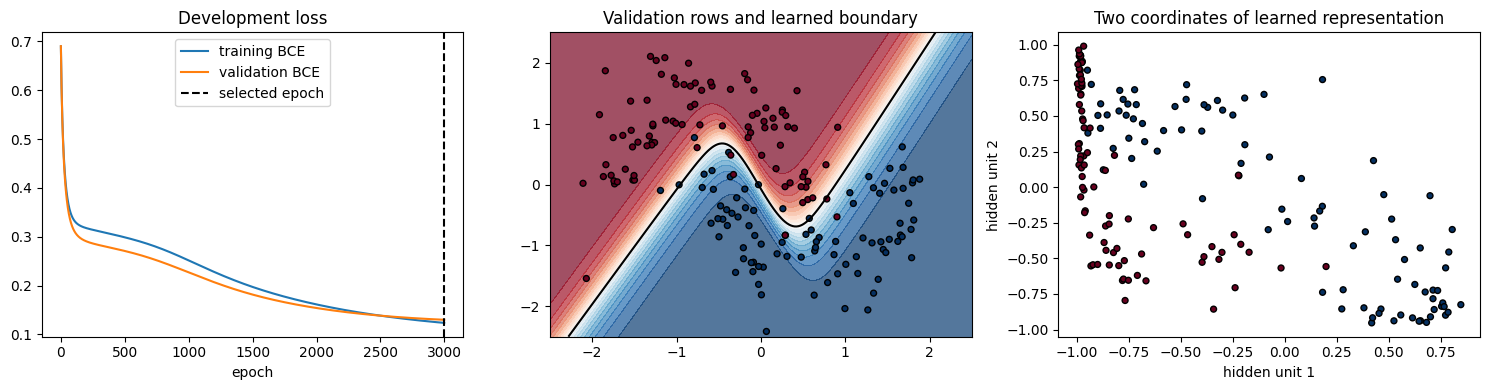

In [10]:
figure_grid_x, figure_grid_y = np.meshgrid(
    np.linspace(-2.5, 2.5, 220),
    np.linspace(-2.5, 2.5, 220),
)
figure_grid = np.column_stack([figure_grid_x.ravel(), figure_grid_y.ravel()])

# Dense grid predictions reveal the nonlinear boundary learned between observed rows.
grid_probabilities = numpy_network.probabilities(figure_grid).reshape(figure_grid_x.shape)

validation_logits, validation_cache = numpy_network.forward(validation_features)
hidden_validation = validation_cache["hidden_activations"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(training_losses, label="training BCE")
axes[0].plot(validation_losses, label="validation BCE")
axes[0].axvline(best_epoch, color="black", linestyle="--", label="selected epoch")
axes[0].set_title("Development loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].contourf(figure_grid_x, figure_grid_y, grid_probabilities, levels=20, cmap="RdBu", alpha=0.7)
axes[1].contour(figure_grid_x, figure_grid_y, grid_probabilities, levels=[0.5], colors="black")
axes[1].scatter(validation_features[:, 0], validation_features[:, 1], c=validation_targets, cmap="RdBu", edgecolor="k", s=18)
axes[1].set_title("Validation rows and learned boundary")

axes[2].scatter(hidden_validation[:, 0], hidden_validation[:, 1], c=validation_targets, cmap="RdBu", edgecolor="k", s=18)
axes[2].set_xlabel("hidden unit 1")
axes[2].set_ylabel("hidden unit 2")
axes[2].set_title("Two coordinates of learned representation")
plt.tight_layout()
plt.show()


In [11]:
class TorchTwoLayerNetwork(nn.Module):
    def __init__(self, input_width, hidden_width):
        super().__init__()
        self.hidden = nn.Linear(input_width, hidden_width)
        self.output = nn.Linear(hidden_width, 1)

    def forward(self, inputs):
        return self.output(torch.tanh(self.hidden(inputs)))


torch_network = TorchTwoLayerNetwork(2, 8)
with torch.no_grad():
    # NumPy stores weights as (input, output); Linear stores (output, input).
    torch_network.hidden.weight.copy_(torch.tensor(best_numpy_state["W1"].T, dtype=torch.float32))
    torch_network.hidden.bias.copy_(torch.tensor(best_numpy_state["b1"], dtype=torch.float32))
    torch_network.output.weight.copy_(torch.tensor(best_numpy_state["W2"].T, dtype=torch.float32))
    torch_network.output.bias.copy_(torch.tensor(best_numpy_state["b2"], dtype=torch.float32))

comparison_inputs_numpy = train_features[:32]
comparison_targets_numpy = train_targets[:32].reshape(-1, 1)

# Use the same rows, parameters, objective, and mean reduction in both systems.
numpy_logits, numpy_cache = numpy_network.forward(comparison_inputs_numpy)
numpy_gradients = numpy_network.backward(comparison_targets_numpy, numpy_cache)

comparison_inputs_torch = torch.tensor(comparison_inputs_numpy, dtype=torch.float32)
comparison_targets_torch = torch.tensor(comparison_targets_numpy, dtype=torch.float32)
torch_network.zero_grad(set_to_none=True)
torch_logits = torch_network(comparison_inputs_torch)
torch_loss = nn.BCEWithLogitsLoss()(torch_logits, comparison_targets_torch)
torch_loss.backward()

print("maximum logit difference:", float(np.max(np.abs(torch_logits.detach().numpy() - numpy_logits))))
print("W1 gradient match:", np.allclose(torch_network.hidden.weight.grad.numpy().T, numpy_gradients["W1"], atol=1e-6))
print("b1 gradient match:", np.allclose(torch_network.hidden.bias.grad.numpy(), numpy_gradients["b1"], atol=1e-6))
print("W2 gradient match:", np.allclose(torch_network.output.weight.grad.numpy().T, numpy_gradients["W2"], atol=1e-6))
print("b2 gradient match:", np.allclose(torch_network.output.bias.grad.numpy(), numpy_gradients["b2"], atol=1e-6))

assert np.allclose(torch_logits.detach().numpy(), numpy_logits, atol=1e-6)
assert np.allclose(torch_network.hidden.weight.grad.numpy().T, numpy_gradients["W1"], atol=1e-6)
assert np.allclose(torch_network.output.weight.grad.numpy().T, numpy_gradients["W2"], atol=1e-6)


maximum logit difference: 8.326462728192041e-07
W1 gradient match: True
b1 gradient match: True
W2 gradient match: True
b2 gradient match: True


## 13 · Mini-project: evaluate the frozen nonlinear model once

**Goal:** prove that a gradient-checked hidden layer improves on a linear baseline
for a nonlinear problem, without test-based tuning.

**Dataset columns:** two standardized coordinates and one binary moon label.

**Workflow:**

1. split before scaling;
2. fit scaling on training rows;
3. calculate the linear validation baseline;
4. gradient-check the scratch model;
5. train with declared width, learning rate, and epoch budget;
6. select and restore by validation BCE;
7. copy the frozen state into `BCEWithLogitsLoss` PyTorch code;
8. verify logits and gradients;
9. evaluate the frozen PyTorch representation once on test rows;
10. report baseline and nonlinear performance without retuning.

Test compares the predeclared linear baseline and frozen network for context. It does
not choose a new architecture, epoch, threshold, or initialization.


In [12]:
linear_test_probabilities = linear_baseline.predict_proba(sealed_test_features_scaled)[:, 1]
linear_test_bce = log_loss(sealed_test_targets, linear_test_probabilities)
linear_test_accuracy = accuracy_score(sealed_test_targets, linear_test_probabilities >= 0.5)

torch_network.eval()
with torch.inference_mode():
    # This is the first and only use of sealed test rows in model evaluation.
    frozen_test_logits = torch_network(
        torch.tensor(sealed_test_features_scaled, dtype=torch.float32)
    )
    frozen_test_probabilities = torch.sigmoid(frozen_test_logits).numpy().ravel()

frozen_test_bce = log_loss(sealed_test_targets, frozen_test_probabilities)
frozen_test_accuracy = accuracy_score(sealed_test_targets, frozen_test_probabilities >= 0.5)

final_test_report = pd.DataFrame(
    [
        {"candidate": "linear baseline", "test_BCE": linear_test_bce, "test_accuracy": linear_test_accuracy},
        {"candidate": "frozen two-layer network", "test_BCE": frozen_test_bce, "test_accuracy": frozen_test_accuracy},
    ]
)
print(final_test_report.round(4).to_string(index=False))
print("final report only; test did not change the network")

assert frozen_test_bce < linear_test_bce


               candidate  test_BCE  test_accuracy
         linear baseline    0.2600         0.9111
frozen two-layer network    0.1195         0.9500
final report only; test did not change the network


## 14 · Practice, solutions, and mastery checkpoint

### Worked example

For input `(5, 2)`, hidden width 4, and one output:

- $W_1$ is `(2,4)` and $b_1$ is `(4,)`;
- hidden activation is `(5,4)`;
- $W_2$ is `(4,1)` and $b_2$ is `(1,)`;
- output logits are `(5,1)`;
- parameter count is $2\times4+4+4+1=17$.

### Guided practice

1. Calculate the neuron logit for `x=[1,2]`, `w=[3,-1]`, `b=0.5`.
2. Prove two affine layers collapse into one.
3. Trace shapes for batch 32, input 6, hidden 10, output 1.
4. Explain why BCE should consume logits.
5. Calculate tanh derivative when activation is `0.6`.

### Independent practice

6. Add a ReLU hidden option with He initialization and gradient checking.
7. Compare three random starts using validation BCE only.
8. Add a second hidden layer, but defer general graph automation to DL-03.
9. Add a three-class softmax output with stable categorical cross-entropy.
10. Compare parameter count and validation evidence for widths 2, 8, and 32.

### Challenge

Rebuild the moons project without copying. Include a numeric neuron, collapse proof,
stable logit BCE, activation-aware initialization, explicit cache, all weight and bias
gradients, full finite-difference check, train-only scaling, validation checkpoint,
PyTorch logit/gradient equivalence, and one sealed-test report.

### Self-check

1. What does a hidden unit calculate before activation?
2. Why does identity activation add no expressive power?
3. What is the difference between a logit and probability?
4. Why is universal approximation not a training guarantee?
5. Why must analytical gradients be checked independently?
6. Why can zero hidden weights preserve symmetry?
7. Which rows select the checkpoint?
8. What did PyTorch equivalence actually verify?

### Solution and scoring rubric

1. Logit is $3(1)-1(2)+0.5=1.5$.
2. Matrix products and combined biases form another affine map.
3. Shapes are `(32,6) → (32,10) → (32,1)`.
4. Stable logit BCE avoids saturated sigmoid followed by `log(0)`.
5. Derivative is $1-0.6^2=0.64$.

Award two points for each self-check and four points for the challenge explanation.
Full credit requires gradient verification and correct data boundaries.

### Common mistakes

- Calling every hidden neuron logistic regression regardless of activation.
- Omitting activation and expecting depth to help.
- Applying sigmoid before a stable logit loss.
- Using He initialization for tanh without justification.
- Forgetting bias gradients.
- Trusting a decreasing loss without gradient checking.
- Mutating or overwriting a hidden forward cache.
- Scaling before the split.
- Reporting training accuracy as generalization.
- Choosing width or epoch from test results.
- Claiming universal approximation guarantees practical success.
- Claiming ReLU eliminates all vanishing gradients.

### Readiness threshold

Score at least **16/20** and correctly explain the forward pass, logit loss,
initialization, chain-rule gradients, gradient check, validation checkpoint, and
NumPy–PyTorch equivalence.


## Ready to move on?

### Quick check

Explain this chain without notes:

neuron logit  
→ batched affine layer  
→ nonlinear hidden representation  
→ output logit  
→ stable BCE  
→ two-layer chain rule  
→ finite-difference verification  
→ validation checkpoint  
→ PyTorch equivalence  
→ one sealed test.

### Teach it back

Explain why XOR needs a hidden nonlinearity, then derive one complete path from loss
to a first-layer weight. Finish by explaining why a low training loss is insufficient.

### Memory aid

**Transform, score, measure loss, trace every derivative, verify numerically, and
trust only the restored validation choice.**

### Next dependency

Verified two-layer chain-rule gradients  
→ required before general backpropagation  
→ because DL-03 turns these repeated local derivatives into a reusable reverse-mode
graph algorithm.
